### Healthcare payment analysis

* Goal: Analysis of gender based payment disparity in pharmaceutical industry
* The input file is preprocessed in general payments and pharmaceutical companies have been filtered.
* Scope General data - Analysis of payments made to individual. For type of payments and form to understand how they are earning and differentiating activies they perform to earn more.
* Date: 21 November 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Dooit_top_level_general_features_avg_NatureOfGift", low_memory=False)
df= df.drop(['Unnamed: 0'],axis=1)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14609233 entries, 0 to 14609232
Data columns (total 70 columns):
 #   Column                                                             Dtype  
---  ------                                                             -----  
 0   Covered_Recipient_Type                                             object 
 1   Teaching_Hospital_Name                                             object 
 2   Covered_Recipient_Profile_ID                                       float64
 3   Covered_Recipient_First_Name                                       object 
 4   Covered_Recipient_Last_Name                                        object 
 5   Recipient_State                                                    object 
 6   Recipient_Country                                                  object 
 7   Covered_Recipient_Primary_Type_1                                   object 
 8   Covered_Recipient_Primary_Type_2                                   object 
 9   

In [4]:
df['Covered_Recipient_Type'].unique()

array(['Covered Recipient Physician',
       'Covered Recipient Non-Physician Practitioner',
       'Covered Recipient Teaching Hospital'], dtype=object)

In [5]:
## Chosing only relevant columns for analysis

nature=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature

,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Royalty or License,6.245356e+08
1,Other_services,4.967668e+08
2,Consulting Fee,4.866362e+08
3,Food and Beverage,2.608382e+08
4,Travel and Lodging,1.619892e+08
5,Acquisitions,7.921103e+07
6,Honoraria,5.348958e+07
7,Education,5.281157e+07
8,faculty_speaker_ed_prog,2.671874e+07
9,Grant,2.432266e+07


In [6]:
nature_gender=df[df['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender


,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Royalty or License,M,6.072483e+08
1,Other_services,M,3.917786e+08
2,Consulting Fee,M,3.901461e+08
3,Food and Beverage,M,1.873355e+08
4,Travel and Lodging,M,1.284185e+08
5,Other_services,F,1.049794e+08
6,Consulting Fee,F,9.648512e+07
7,Acquisitions,M,7.565090e+07
8,Food and Beverage,F,7.349558e+07
9,Honoraria,M,4.233715e+07


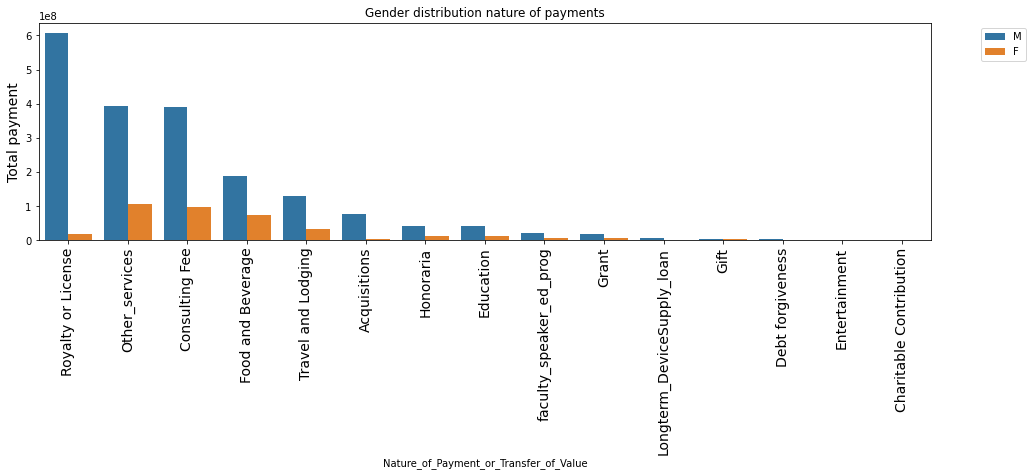

In [7]:
my_palette=my_palette ={"F": "C1", "M": "C0"}

g=sns.barplot(data=nature_gender, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution nature of payments")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [8]:
df['Covered_Recipient_Profile_ID']=df['Covered_Recipient_Profile_ID'].astype(object)

In [9]:
top_sorted_profiles=df.groupby(['Covered_Recipient_Profile_ID', 'Covered_Recipient_gender' ])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()


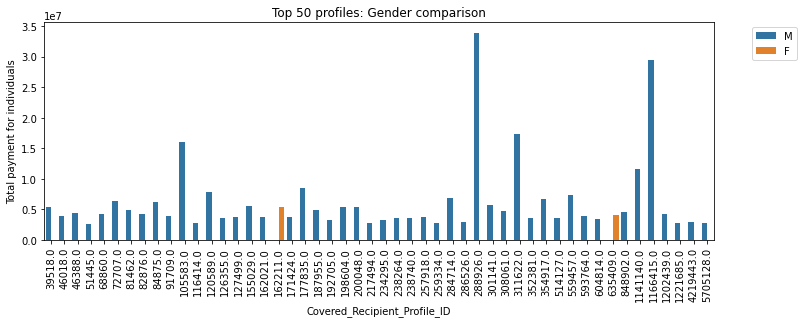

In [10]:
g=sns.barplot(data=top_sorted_profiles[:50], x='Covered_Recipient_Profile_ID', y='Total_Amount_of_Payment_USDollars', 
              hue='Covered_Recipient_gender').set_title("Top 50 profiles: Gender comparison")
g.figure.set_size_inches(12, 4)
plt.ylabel("Total payment for individuals")
plt.xticks(rotation=90)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [11]:
## Capturing the profile ID and related records to sum up individual payments and understand types
index_list=[]
for i in top_sorted_profiles['Covered_Recipient_Profile_ID'][:50].values:
    ind_index=df[df['Covered_Recipient_Profile_ID']==i].index
    index_list.extend(ind_index)


In [12]:
top_ind_transactions=df.iloc[index_list].reset_index()

In [13]:
top_ind_transactions=top_ind_transactions[['Covered_Recipient_Type','Covered_Recipient_Profile_ID','Covered_Recipient_Primary_Type_1',
                                          'Average_payment','Total_Amount_of_Payment_USDollars','Form_of_Payment_or_Transfer_of_Value',
                                          'Number_of_Payments_Included_in_Total_Amount', 'Charity_Indicator','Covered_Recipient_gender','City_of_Travel',
                                          'Nature_of_Payment_or_Transfer_of_Value','Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name']]


In [14]:
top_ind_transactions.describe()

,Average_payment,Total_Amount_of_Payment_USDollars,Number_of_Payments_Included_in_Total_Amount
count,1.995000e+03,1.995000e+03,1995.000000
mean,1.533737e+05,1.534239e+05,1.090727
std,7.253079e+05,7.252997e+05,3.630542
min,2.500000e-01,2.500000e-01,1.000000
25%,3.499000e+01,3.500000e+01,1.000000
50%,3.750000e+02,3.750000e+02,1.000000
75%,4.000000e+03,4.000000e+03,1.000000
max,1.030716e+07,1.030716e+07,163.000000


In [15]:
top_ind_transactions.describe(include=object)

,Covered_Recipient_Type,Covered_Recipient_Profile_ID,Covered_Recipient_Primary_Type_1,Form_of_Payment_or_Transfer_of_Value,Charity_Indicator,Covered_Recipient_gender,City_of_Travel,Nature_of_Payment_or_Transfer_of_Value,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name
count,1995,1995.0,1995,1995,376,1995,308,1995,1995
unique,1,50.0,1,2,1,2,57,9,75
top,Covered Recipient Physician,84875.0,Medical Doctor,Cash or cash equivalent,No,M,naples,Food and Beverage,"zimmer biomet holdings, inc."
freq,1995,232.0,1995,1127,376,1990,41,632,743


In [16]:
top_profiles=top_ind_transactions.groupby(['Covered_Recipient_Profile_ID','Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
                              'Nature_of_Payment_or_Transfer_of_Value','Form_of_Payment_or_Transfer_of_Value',
                             'Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().reset_index()


top_profiles


,Covered_Recipient_Profile_ID,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Nature_of_Payment_or_Transfer_of_Value,Form_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,39518.0,"zimmer biomet holdings, inc.",Royalty or License,Cash or cash equivalent,M,5286459.16
1,46018.0,asklepios biopharmaceutical inc.,Acquisitions,Cash or cash equivalent,M,3944327.67
2,46388.0,"arthrex, inc.",Consulting Fee,Cash or cash equivalent,M,15330.00
3,46388.0,"arthrex, inc.",Food and Beverage,In-kind items and services,M,683.98
4,46388.0,"arthrex, inc.",Other_services,Cash or cash equivalent,M,119718.01
...,...,...,...,...,...,...
276,5705128.0,"medtronic, inc.",Other_services,Cash or cash equivalent,M,20875.00
277,5705128.0,"medtronic, inc.",Travel and Lodging,In-kind items and services,M,6115.04
278,5705128.0,monteris medical corporation,Food and Beverage,In-kind items and services,M,139.00
279,5705128.0,omniscient neurotechnology america ltd,Food and Beverage,Cash or cash equivalent,M,26.19


In [17]:
## Payers paying to high profile people
print("Entities paying very high value payments to Physicians")
top_profiles[(top_profiles['Nature_of_Payment_or_Transfer_of_Value']=='Royalty or License')|
             (top_profiles['Nature_of_Payment_or_Transfer_of_Value']=='Acquisitions')][['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
                                                                                            'Nature_of_Payment_or_Transfer_of_Value']].value_counts()

Entities paying very high value payments to Physicians


Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name  Nature_of_Payment_or_Transfer_of_Value
zimmer biomet holdings, inc.                                   Royalty or License                        19
arthrex, inc.                                                  Royalty or License                         6
depuy synthes products, inc.                                   Royalty or License                         5
medtronic, inc.                                                Royalty or License                         5
abbvie inc.                                                    Royalty or License                         2
stryker corporation                                            Royalty or License                         2
smith+nephew, inc.                                             Royalty or License                         2
nuvasive, inc.                                                 Royalty or License                         2
medtronic, inc.                   

In [18]:
## Payers paying to high profile people
print("Entities paying very high value payments to Physicians")
top_payers=top_profiles[(top_profiles['Nature_of_Payment_or_Transfer_of_Value']=='Royalty or License')|
             (top_profiles['Nature_of_Payment_or_Transfer_of_Value']=='Acquisitions')]

top_payers.groupby(['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
                    'Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).sort_values(ascending=False).reset_index()


Entities paying very high value payments to Physicians


,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,"zimmer biomet holdings, inc.",Royalty or License,83746069.29
1,"arthrex, inc.",Royalty or License,55053155.53
2,abbvie inc.,Royalty or License,41034066.06
3,"medtronic, inc.",Royalty or License,26485677.00
4,"livanova usa, inc.",Royalty or License,16065515.51
5,"depuy synthes products, inc.",Royalty or License,11598897.28
6,asklepios biopharmaceutical inc.,Acquisitions,11267132.60
7,stryker corporation,Royalty or License,9261749.40
8,"medtronic, inc.",Acquisitions,5340446.50
9,"walk vascular, llc",Acquisitions,4846659.06


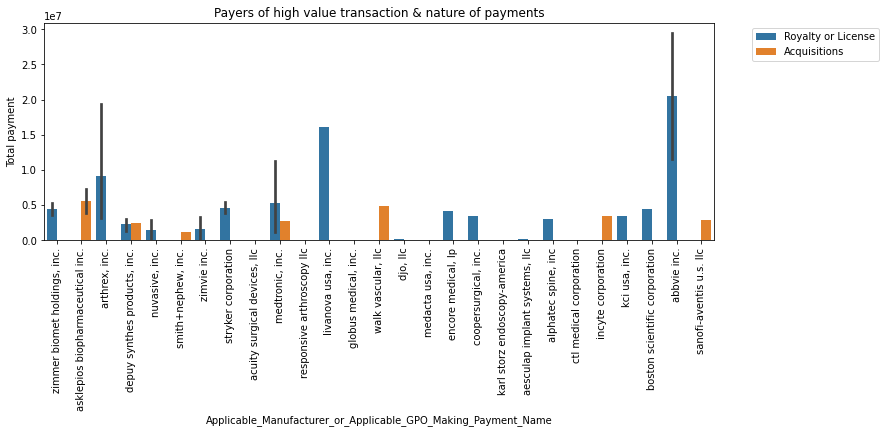

In [19]:
g=sns.barplot(data=top_payers, x='Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name', y='Total_Amount_of_Payment_USDollars', 
              hue='Nature_of_Payment_or_Transfer_of_Value').set_title("Payers of high value transaction & nature of payments")
g.figure.set_size_inches(12, 4)
plt.ylabel("Total payment")
plt.xticks(rotation=90)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [20]:
## Types of payment to high profile physicians
print('Type of payments and value to high profile individuals')
top_type=top_profiles.groupby(['Covered_Recipient_Profile_ID','Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_type


Type of payments and value to high profile individuals


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,288926.0,Royalty or License,33922024.93
1,1166415.0,Royalty or License,29433942.06
2,311622.0,Royalty or License,17296899.00
3,105583.0,Royalty or License,16065515.51
4,1141140.0,Royalty or License,11600124.00
...,...,...,...
139,238264.0,Other_services,130.68
140,593764.0,Food and Beverage,126.93
141,91709.0,Food and Beverage,105.77
142,4219443.0,Food and Beverage,35.00


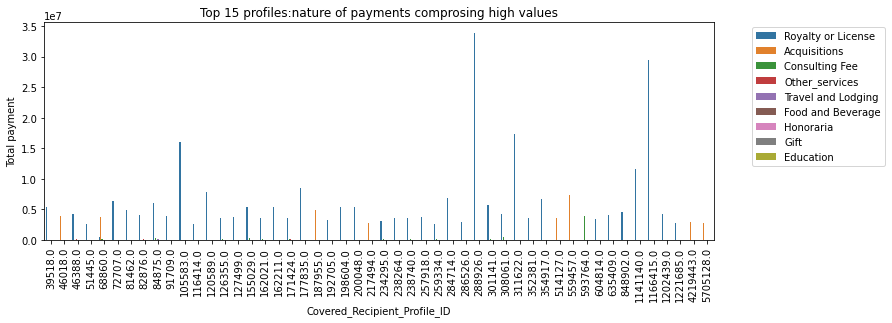

In [21]:
g=sns.barplot(data=top_type, x='Covered_Recipient_Profile_ID', y='Total_Amount_of_Payment_USDollars', 
              hue='Nature_of_Payment_or_Transfer_of_Value').set_title("Top 15 profiles:nature of payments comprosing high values")
g.figure.set_size_inches(12, 4)
plt.ylabel("Total payment")
plt.xticks(rotation=90)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [22]:
top_ind_transactions['Form_of_Payment_or_Transfer_of_Value'].value_counts()
                                                            

Form_of_Payment_or_Transfer_of_Value
Cash or cash equivalent       1127
In-kind items and services     868
Name: count, dtype: int64

### Observations
* The top transactions are related to royalty or license and acquitions. 
* The physicians are able to get better finalcial stakes through royalty and acquisitions.


In [27]:
## No 1 receiver
top_ind_transactions[top_ind_transactions['Covered_Recipient_Profile_ID']==288926.0][['Nature_of_Payment_or_Transfer_of_Value','Total_Amount_of_Payment_USDollars']]



,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Royalty or License,28276.04
1,Royalty or License,609811.28
2,Royalty or License,5627811.09
3,Royalty or License,8648793.03
4,Royalty or License,8700174.90
5,Royalty or License,10307158.59


In [28]:
## No 2 receiver
top_ind_transactions[top_ind_transactions['Covered_Recipient_Profile_ID']==1166415.0][['Nature_of_Payment_or_Transfer_of_Value','Total_Amount_of_Payment_USDollars']]



,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
6,Royalty or License,7770644.00
7,Food and Beverage,147.05
8,Royalty or License,4208250.00
9,Royalty or License,7385187.00
10,Royalty or License,10069861.06
11,Food and Beverage,129.43
12,Food and Beverage,137.39


## Observations
* The top paid people get lot of rolayties. 
* Acquition related payments are high value.
* For paying entities this are biggest expenses.